In [1]:
from transformers import GPT2LMHeadModel 

/Users/vaibhav/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")

sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k)
    print(v.shape)
    

transformer.wte.weight
torch.Size([50257, 768])
transformer.wpe.weight
torch.Size([1024, 768])
transformer.h.0.ln_1.weight
torch.Size([768])
transformer.h.0.ln_1.bias
torch.Size([768])
transformer.h.0.attn.c_attn.weight
torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias
torch.Size([2304])
transformer.h.0.attn.c_proj.weight
torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias
torch.Size([768])
transformer.h.0.ln_2.weight
torch.Size([768])
transformer.h.0.ln_2.bias
torch.Size([768])
transformer.h.0.mlp.c_fc.weight
torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias
torch.Size([3072])
transformer.h.0.mlp.c_proj.weight
torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias
torch.Size([768])
transformer.h.1.ln_1.weight
torch.Size([768])
transformer.h.1.ln_1.bias
torch.Size([768])
transformer.h.1.attn.c_attn.weight
torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias
torch.Size([2304])
transformer.h.1.attn.c_proj.weight
torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias


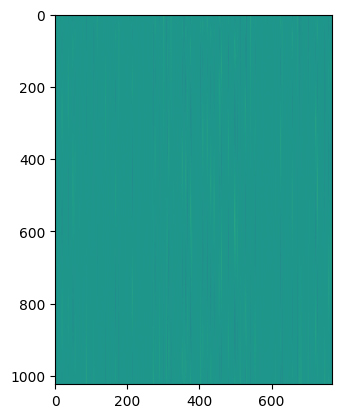

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(sd_hf['transformer.wpe.weight'])

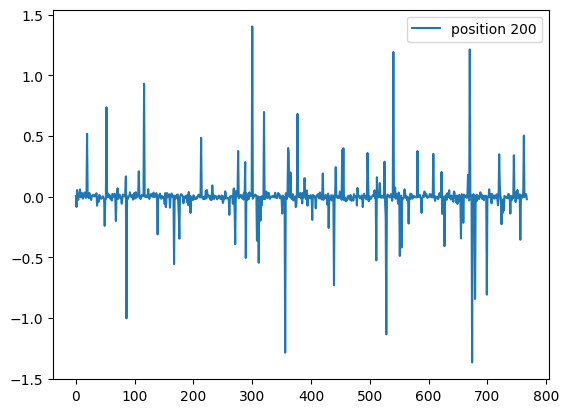

In [12]:
pos_emb_0 = sd_hf['transformer.wpe.weight'][0,:]
pos_emb_1 = sd_hf['transformer.wpe.weight'][1,:]
pos_emb_2 = sd_hf['transformer.wpe.weight'][2,:]

# plt.plot(pos_emb_0, label='position 0')
# plt.plot(pos_emb_1, label='position 100')
plt.plot(pos_emb_2, label='position 200')
plt.legend()


In [14]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, and my project is based on the idea of a language model.\n\nI want to have a language that's both expressive and readable.\n\nLet's look at the following code:\n\nimport Data.ByteString\n\ndef get ( self ):\n\nself.data = Data.ByteString(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data"},
 {'generated_text': "Hello, I'm a language model, not a language model, and if I don't understand it, I won't learn to write it. So I was writing a system for programming in JavaScript and a s

In [15]:
with open('input.txt', 'r') as f:
    text = f.read()



In [18]:
import tiktoken
import torch
enc = tiktoken.get_encoding("gpt2")
text_encoding = torch.tensor(enc.encode(text), dtype=torch.long)
print(text_encoding[0:24])

tensor([ 5962, 22307,    25,   198,  8421,   356,  5120,   597,  2252,    11,
         3285,   502,  2740,    13,   198,   198,  3237,    25,   198,  5248,
          461,    11,  2740,    13])


In [22]:
x = text_encoding[:24 + 1]

input = x[:-1]
target = x[1:]
input = input.view(4, 6)
target = target.view(4, 6)
print(input)
print(target)



tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])
